In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader

In [15]:
df = pd.read_csv(r"/content/IMDB-Dataset.csv")

if "review" in df.columns and "sentiment" in df.columns:
    df = df.rename(columns={"review": "text", "sentiment": "label"})

if "text" not in df.columns or "label" not in df.columns:
    df.columns = ["text", "label"]

df["text"] = df["text"].astype(str).str.lower().str.split()
df["label"] = df["label"].astype(str).str.strip().str.lower()

df = df[df["label"].isin(["positive", "negative"])].copy()

In [16]:
df.head()

,text,label
0,"[one, of, the, other, reviewers, has, mentione...",positive
1,"[a, wonderful, little, production., <br, /><br...",positive
2,"[i, thought, this, was, a, wonderful, way, to,...",positive
3,"[basically, there's, a, family, where, a, litt...",negative
4,"[petter, mattei's, ""love, in, the, time, of, m...",positive


In [17]:
df.shape

(50000, 2)

In [18]:
df = df[:5000]

In [19]:
df.shape

(5000, 2)

In [20]:
le = LabelEncoder()
df["label"] = le.fit_transform(df["label"])
print("Classes:", list(le.classes_))
print(df["label"].value_counts())

Classes: ['negative', 'positive']
label
0    2532
1    2468
Name: count, dtype: int64


In [21]:
df

,text,label
0,"[one, of, the, other, reviewers, has, mentione...",1
1,"[a, wonderful, little, production., <br, /><br...",1
2,"[i, thought, this, was, a, wonderful, way, to,...",1
3,"[basically, there's, a, family, where, a, litt...",0
4,"[petter, mattei's, ""love, in, the, time, of, m...",1
...,...,...
4995,"[an, interesting, slasher, film, with, multipl...",0
4996,"[i, watched, this, series, when, it, first, ca...",1
4997,"[once, again, jet, li, brings, his, charismati...",1
4998,"[i, rented, this, movie,, after, hearing, chri...",0


In [22]:
train_data, test_data = train_test_split(df, test_size=0.2, random_state=42)

vocab = {word for phrase in df["text"] for word in phrase}
word_to_idx = {word: idx for idx, word in enumerate(vocab, start=1)}

max_length = 200

def encode_and_pad(text):
    encoded = [word_to_idx.get(word, 0) for word in text[:max_length]]
    encoded = encoded + [0] * (max_length - len(encoded))
    return encoded

train_data["text"] = train_data["text"].apply(encode_and_pad)
test_data["text"] = test_data["text"].apply(encode_and_pad)

In [23]:
train_data['text']

,text
4227,"[80222, 34347, 37377, 44160, 13370, 32086, 310..."
4676,"[89681, 68975, 24366, 74520, 50157, 76450, 586..."
800,"[66827, 74520, 77257, 68450, 49636, 66611, 745..."
3671,"[80222, 39109, 70319, 17506, 56365, 4662, 2869..."
4193,"[6799, 105, 13146, 37592, 53340, 78459, 71242,..."
...,...
4426,"[1394, 68131, 49414, 23252, 42502, 58692, 4963..."
466,"[80981, 3819, 54489, 49356, 80093, 23252, 2156..."
3092,"[59979, 42502, 35738, 24959, 40016, 2838, 7645..."
3772,"[32313, 83221, 54614, 83144, 77121, 27389, 524..."


In [24]:
class SentimentDataset(Dataset):
    def __init__(self, data):
        self.texts = data['text'].values
        self.labels = data['label'].values

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        return torch.tensor(text, dtype=torch.long), torch.tensor(label, dtype=torch.long)

train_dataset = SentimentDataset(train_data)
test_dataset = SentimentDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [25]:
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(SentimentRNN, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.RNN(embed_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.embedding(x)
        h0 = torch.zeros(1, x.size(0), hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

vocab_size = len(vocab) + 1
embed_size = 128
hidden_size = 128
output_size = 2
model = SentimentRNN(vocab_size, embed_size, hidden_size, output_size)

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for texts, labels in train_loader:
        outputs = model(texts)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}')

Epoch [1/10], Loss: 0.7074
Epoch [2/10], Loss: 0.6711
Epoch [3/10], Loss: 0.6355
Epoch [4/10], Loss: 0.5857
Epoch [5/10], Loss: 0.5114
Epoch [6/10], Loss: 0.4634
Epoch [7/10], Loss: 0.4273
Epoch [8/10], Loss: 0.4103
Epoch [9/10], Loss: 0.4050
Epoch [10/10], Loss: 0.4016


In [27]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for texts, labels in test_loader:
        outputs = model(texts)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 51.90%


Epoch [1/10], Loss: 0.4022
Epoch [2/10], Loss: 0.4121
Epoch [3/10], Loss: 0.4404
Epoch [4/10], Loss: 0.4144
Epoch [5/10], Loss: 0.4078
Epoch [6/10], Loss: 0.4043
Epoch [7/10], Loss: 0.4027
Epoch [8/10], Loss: 0.4066
Epoch [9/10], Loss: 0.4046
Epoch [10/10], Loss: 0.3964


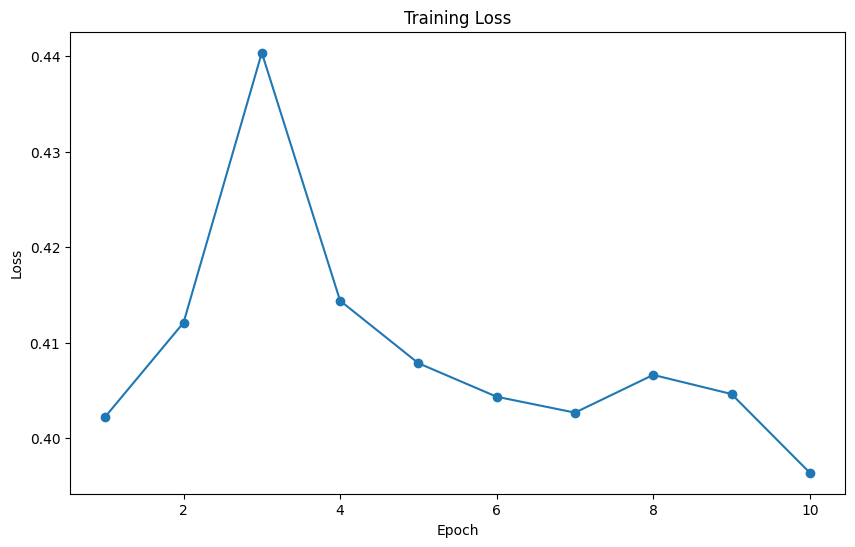

In [28]:
losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for texts, labels in train_loader:
        outputs = model(texts)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss / len(train_loader))
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss / len(train_loader):.4f}')

plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [29]:
texts, labels = next(iter(train_loader))
outputs = model(texts)
loss = criterion(outputs, labels)
print("Batch output shape:", outputs.shape)
print("Batch labels shape:", labels.shape)
print("Sanity loss:", float(loss.item()))

Batch output shape: torch.Size([32, 2])
Batch labels shape: torch.Size([32])
Sanity loss: 0.3386574983596802
